# Лабораторная работа №2: Обнаружение аномалий и выбросов в  данных
### Задание 1. Загрузка и профилирование данных

Размер датасета: 1000 строк, 9 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
Количество пропусков по столбцам:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Диапазон числовых значение:
                Минимальное:   Максимальное:   Диап

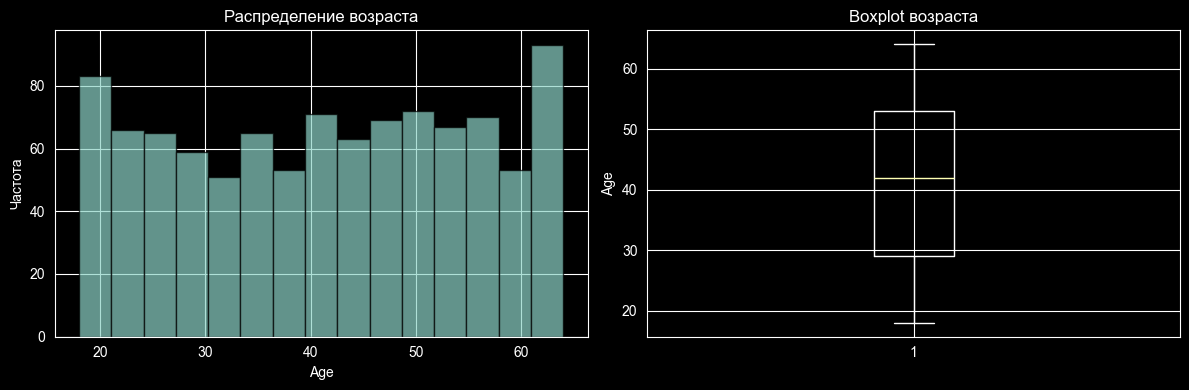

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/retail_sales_dataset.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

# Информация о столбцах и типах
df.info()
# Статистика по числовым признакам
df.describe()

print('Количество пропусков по столбцам:')
print(df.isnull().sum())

print('Диапазон числовых значение:')
number_col = df.select_dtypes(include='number')
result_range = pd.DataFrame({
    'Минимальное: ' : number_col.min(),
    'Максимальное: ' : number_col.max(),
    'Диапазон: ' : number_col.max() - number_col.min()
})
print(result_range)

def find_extremes_percentile(data, column, percentile=1):
    lower_thresh = data[column].quantile(percentile / 100)
    upper_thresh = data[column].quantile(1 - percentile / 100)

    extremes = data[(data[column] <= lower_thresh) | (data[column] >= upper_thresh)]
    return  extremes, lower_thresh, upper_thresh
for column in number_col.columns:
    extremes_1, lower_1, upper_1 = find_extremes_percentile(df, column, 1)
    print('Столбец: ', column)
    print(f'Экстремальные (1%): от {lower_1} до {upper_1}')
    print(f"Количество экстремальных значений: {len(extremes_1)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Возраст
# Гистограмма
axes[0].hist(df['Age'], bins=15, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Частота')
# Boxplot
axes[1].boxplot(df['Age'])
axes[1].set_title('Boxplot возраста')
axes[1].set_ylabel('Age')
plt.tight_layout()
plt.show()

#### Вывод о возможных выбросах
- Гистограмма: примерно равномерное распределение с небольшим смещением в сторону старших возрастов
- Boxplot: выбросов не обнаружено - все точки в пределах усов

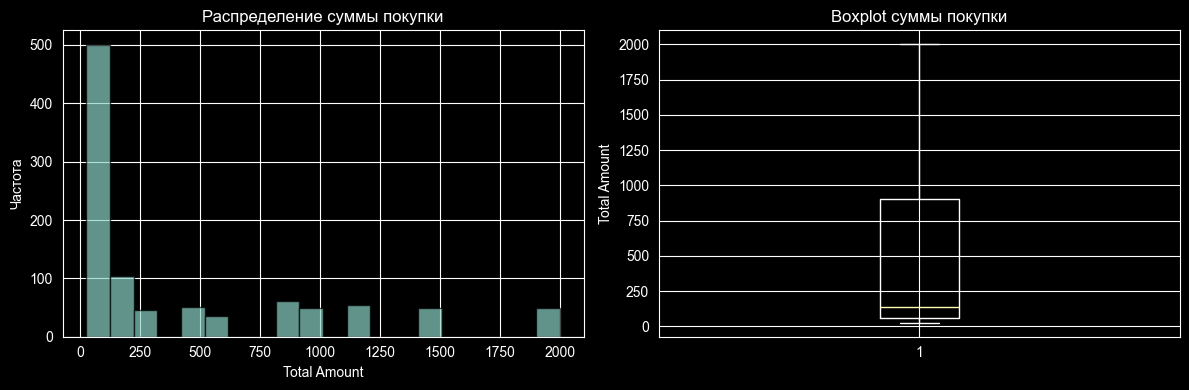

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Гистограмма
axes[0].hist(df['Total Amount'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение суммы покупки')
axes[0].set_xlabel('Total Amount')
axes[0].set_ylabel('Частота')
# Boxplot
axes[1].boxplot(df['Total Amount'])
axes[1].set_title('Boxplot суммы покупки')
axes[1].set_ylabel('Total Amount')
plt.tight_layout()
plt.show()

#### Вывод о возможных выбросах
- Гистограмма: распределение сильно скошено вправо — большинство покупок на небольшие суммы (25-300)
- Boxplot: выбросов не обнаружено - все точки в пределах усов

### Задание 2. Проверка нормальности распределения

Описательные характеристики:
         Строка  Среднее  Медиана  Стандартное отклонение  \
0           Age   41.392     42.0               13.681430   
1  Total Amount  456.000    135.0              559.997632   

   Коэффицент асимметрии  Коэффицент эксцесса  
0              -0.048739            -1.201208  
1               1.374063             0.804968  


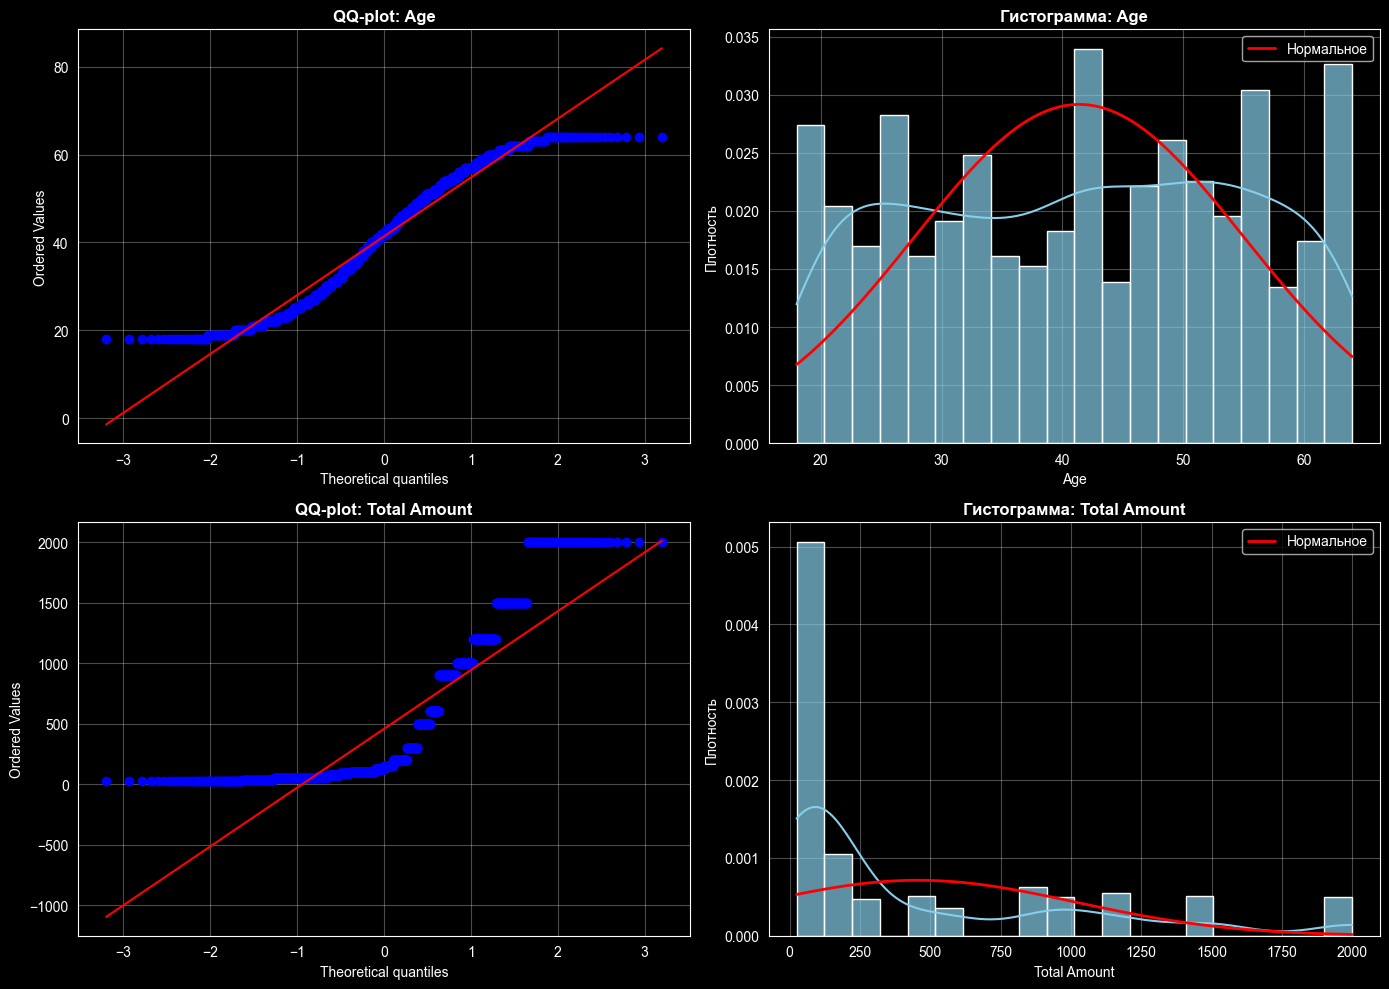

In [3]:
from scipy import stats
import numpy as np
features = ['Age', 'Total Amount']
print('Описательные характеристики:')
specifications_result = []
for feature in features:
    specifications_result.append({
        'Строка' : feature,
        'Среднее' : df[feature].mean(),
        'Медиана' : df[feature].median(),
        'Стандартное отклонение' : df[feature].std(),
        'Коэффицент асимметрии' : stats.skew(df[feature]),
        'Коэффицент эксцесса' : stats.kurtosis(df[feature])
    })
print(pd.DataFrame(specifications_result))


# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features):
    # QQ-plot
    stats.probplot(df[feature], dist="norm", plot=axes[idx, 0])
    axes[idx, 0].set_title(f'QQ-plot: {feature}', fontsize=12, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)

    # Гистограмма с кривой нормального распределения
    sns.histplot(data=df, x=feature, bins=20, kde=True,
                 stat='density', alpha=0.7, color='skyblue', ax=axes[idx, 1])

    # Кривая нормального распределения
    mu, std = df[feature].mean(), df[feature].std()
    x = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[idx, 1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Нормальное')

    axes[idx, 1].set_title(f'Гистограмма: {feature}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(feature)
    axes[idx, 1].set_ylabel('Плотность')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



#### Age:
- QQ-график имеет S-образную форму
- Плосковершинное распределение
- График не совпадает с графиком нормального распределения
#### Total Amount:
- QQ-график сильно изогнут вверх
- Правосторонняя асимметрия
- График не совпадает с графиком нормального распределения

In [4]:
features = ['Age', 'Total Amount']
# Уровень значимости
alpha = 0.05
print("ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (КРИТЕРИЙ ШАПИРО-УИЛКА)")

print("\nГИПОТЕЗЫ:")
print("   H₀: выборка подчиняется нормальному распределению")
print("   H₁: выборка НЕ подчиняется нормальному распределению")
print(f"\n   Уровень значимости α = {alpha}")
print(f"   Правило: если p-value < {alpha} → отвергаем H₀")

for feature in features:
    # Критерий Шапиро-Уилка
    statistic, p_value = stats.shapiro(df[feature])

    print(f"\n {feature}:")
    print(f"   • Статистика W = {statistic:.6f}")
    print(f"   • p-value = {p_value}")

    if p_value < alpha:
        print(f"   • Результат: p-value ({p_value}) < {alpha}")
        print(f"   • Решение: ОТВЕРГАЕМ H₀")
        print(f"   • Вывод: Распределение {feature} НЕ является нормальным")
    else:
        print(f"   • Результат: p-value ({p_value}) ≥ {alpha}")
        print(f"   • Решение: НЕТ ОСНОВАНИЙ ОТВЕРГНУТЬ H₀")
        print(f"   • Вывод: Распределение {feature} может быть нормальным")

ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (КРИТЕРИЙ ШАПИРО-УИЛКА)

ГИПОТЕЗЫ:
   H₀: выборка подчиняется нормальному распределению
   H₁: выборка НЕ подчиняется нормальному распределению

   Уровень значимости α = 0.05
   Правило: если p-value < 0.05 → отвергаем H₀

 Age:
   • Статистика W = 0.952415
   • p-value = 1.8233998212466617e-17
   • Результат: p-value (1.8233998212466617e-17) < 0.05
   • Решение: ОТВЕРГАЕМ H₀
   • Вывод: Распределение Age НЕ является нормальным

 Total Amount:
   • Статистика W = 0.748911
   • p-value = 2.1785847545499362e-36
   • Результат: p-value (2.1785847545499362e-36) < 0.05
   • Решение: ОТВЕРГАЕМ H₀
   • Вывод: Распределение Total Amount НЕ является нормальным


### Задание 3. Обнаружение выбросов статистическими методами
#### 1. Метод Z-score

ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ Z-SCORE
Признак: Age
   Среднее (μ): 41.39
   Стандартное отклонение (σ): 13.68
Оценка Z-score для Age:
0     -0.540294
1     -1.125029
2      0.629174
3     -0.321019
4     -0.832662
         ...   
995    1.506275
996    0.775358
997   -1.344304
998   -0.394111
999    0.409899
Name: Age, Length: 1000, dtype: float64

ОПРЕДЕЛЕНИЕ ВЫБРОСОВ
   Пороговое значение: |Z| > 3
   Нижняя граница: 0.34771102263242426
   Верхняя граница: 82.43628897736758
   Количество выбросов: 0 (0.00%)


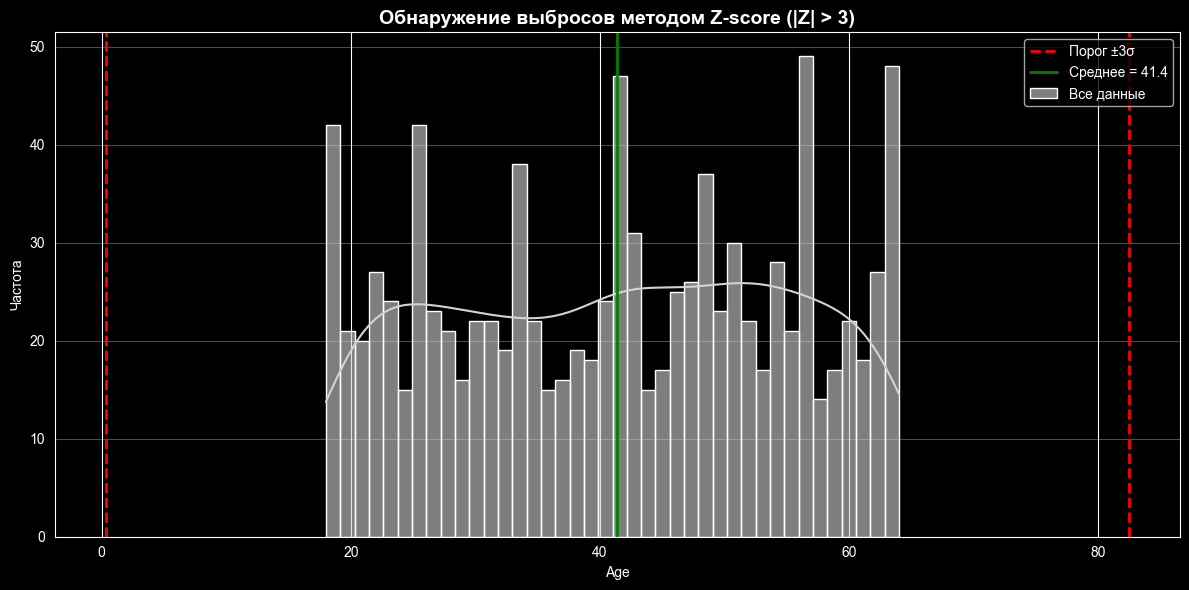

In [5]:
feature = 'Age'
data = df[feature]
print("ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ Z-SCORE")
print(f"Признак: {feature}")
# Расчет среднего и стандартного отклонения
mean_val = data.mean()
std_val = data.std()
print(f"   Среднее (μ): {mean_val:.2f}")
print(f"   Стандартное отклонение (σ): {std_val:.2f}")
# Расчет Z-оценок: z = (x - μ) / σ
z_scores = (data - mean_val) / std_val
print(f'Оценка Z-score для {feature}:')
print(z_scores)

print("\nОПРЕДЕЛЕНИЕ ВЫБРОСОВ")
threshold = 3
outliers_mask = np.abs(z_scores) > threshold
outliers_count = outliers_mask.sum()
outliers_values = data[outliers_mask].values
outliers_percentage = (outliers_count / len(data)) * 100
lower_bound = mean_val - threshold * std_val
upper_bound = mean_val + threshold * std_val
print(f"   Пороговое значение: |Z| > {threshold}")
print(f"   Нижняя граница: {lower_bound}")
print(f"   Верхняя граница: {upper_bound}")
print(f"   Количество выбросов: {outliers_count} ({outliers_percentage:.2f}%)")


outlier_data = data[outliers_mask]
plt.figure(figsize=(12, 6))
sns.histplot(data, bins=40, kde=True, color='lightgray', alpha=0.6, label='Все данные')
# Выделение выбросов
if outliers_count > 0:
    plt.hist(outlier_data, bins=10, color='red', alpha=0.8,
             label=f'Выбросы: {outliers_count} ({outliers_percentage:.2f}%)')
plt.axvline(lower_bound, color='red', linestyle='--', linewidth=2,
            label=f'Порог ±3σ')
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2)
plt.axvline(mean_val, color='green', linestyle='-', linewidth=2,
            label=f'Среднее = {mean_val:.1f}')

plt.title(f'Обнаружение выбросов методом Z-score (|Z| > {threshold})',
          fontweight='bold', fontsize=14)
plt.xlabel(feature)
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Метод IQR

In [6]:
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1: ', Q1)
print('Q3: ', Q3)
print('IQR: ', IQR)
print('Нижняя граница: ', lower_bound)
print('Верхняя граница: ', upper_bound)

outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}')

Q1:  29.0
Q3:  53.0
IQR:  24.0
Нижняя граница:  -7.0
Верхняя граница:  89.0
Выбросов по методу IQR: 0


#### Сравнение методов:
- Z-score: нижняя граница ≈ 0, верхняя граница ≈ 83, количество выбросов при |Z| > 3 = 0
- IQR: нижняя граница = -7, верхняя граница = 89, количество выбросов = 0
#### Cравнительный анализ методов:
##### Z-score:
- Распределение близко к нормальному
- Не устойчив к выбросам
- Не работает с асимметрией
##### IQR:
- Распределение не нормальное (скошено)
- Устойчив к выбросам
- Работает с асимметрией

### Задание 4. Метод локальной плотности


1. Масштабирование признаков (StandardScaler)
   Форма данных: (1000, 2)
   Среднее после масштабирования: -0.00
   Стандартное отклонение после масштабирования: 1.00


МЕТОД 1: РАССТОЯНИЕ ДО k-ГО СОСЕДА

Euclidean расстояние (k=10):
  Порог: 0.3656
  Аномалий: 43 (4.30%)

Manhattan расстояние (k=10):
  Порог: 0.3997
  Аномалий: 50 (5.00%)


МЕТОД 2: СРЕДНЕЕ РАССТОЯНИЕ ДО k СОСЕДЕЙ
Анализ для разных значений k:
  Euclidean (k=5): 50 аномалий (5.00%)
  Manhattan (k=5): 43 аномалий (4.30%)
  Euclidean (k=7): 50 аномалий (5.00%)
  Manhattan (k=7): 50 аномалий (5.00%)
  Euclidean (k=9): 50 аномалий (5.00%)
  Manhattan (k=9): 50 аномалий (5.00%)
  Euclidean (k=10): 50 аномалий (5.00%)
  Manhattan (k=10): 50 аномалий (5.00%)


МЕТОД 3: ОЦЕНКА ЛОКАЛЬНОЙ ПЛОТНОСТИ
  Euclidean (k=5): 50 аномалий (5.00%)
  Manhattan (k=5): 43 аномалий (4.30%)
  Euclidean (k=7): 50 аномалий (5.00%)
  Manhattan (k=7): 50 аномалий (5.00%)
  Euclidean (k=9): 50 аномалий (5.00%)
  Manhattan (k=9): 50 аномалий (5.00%

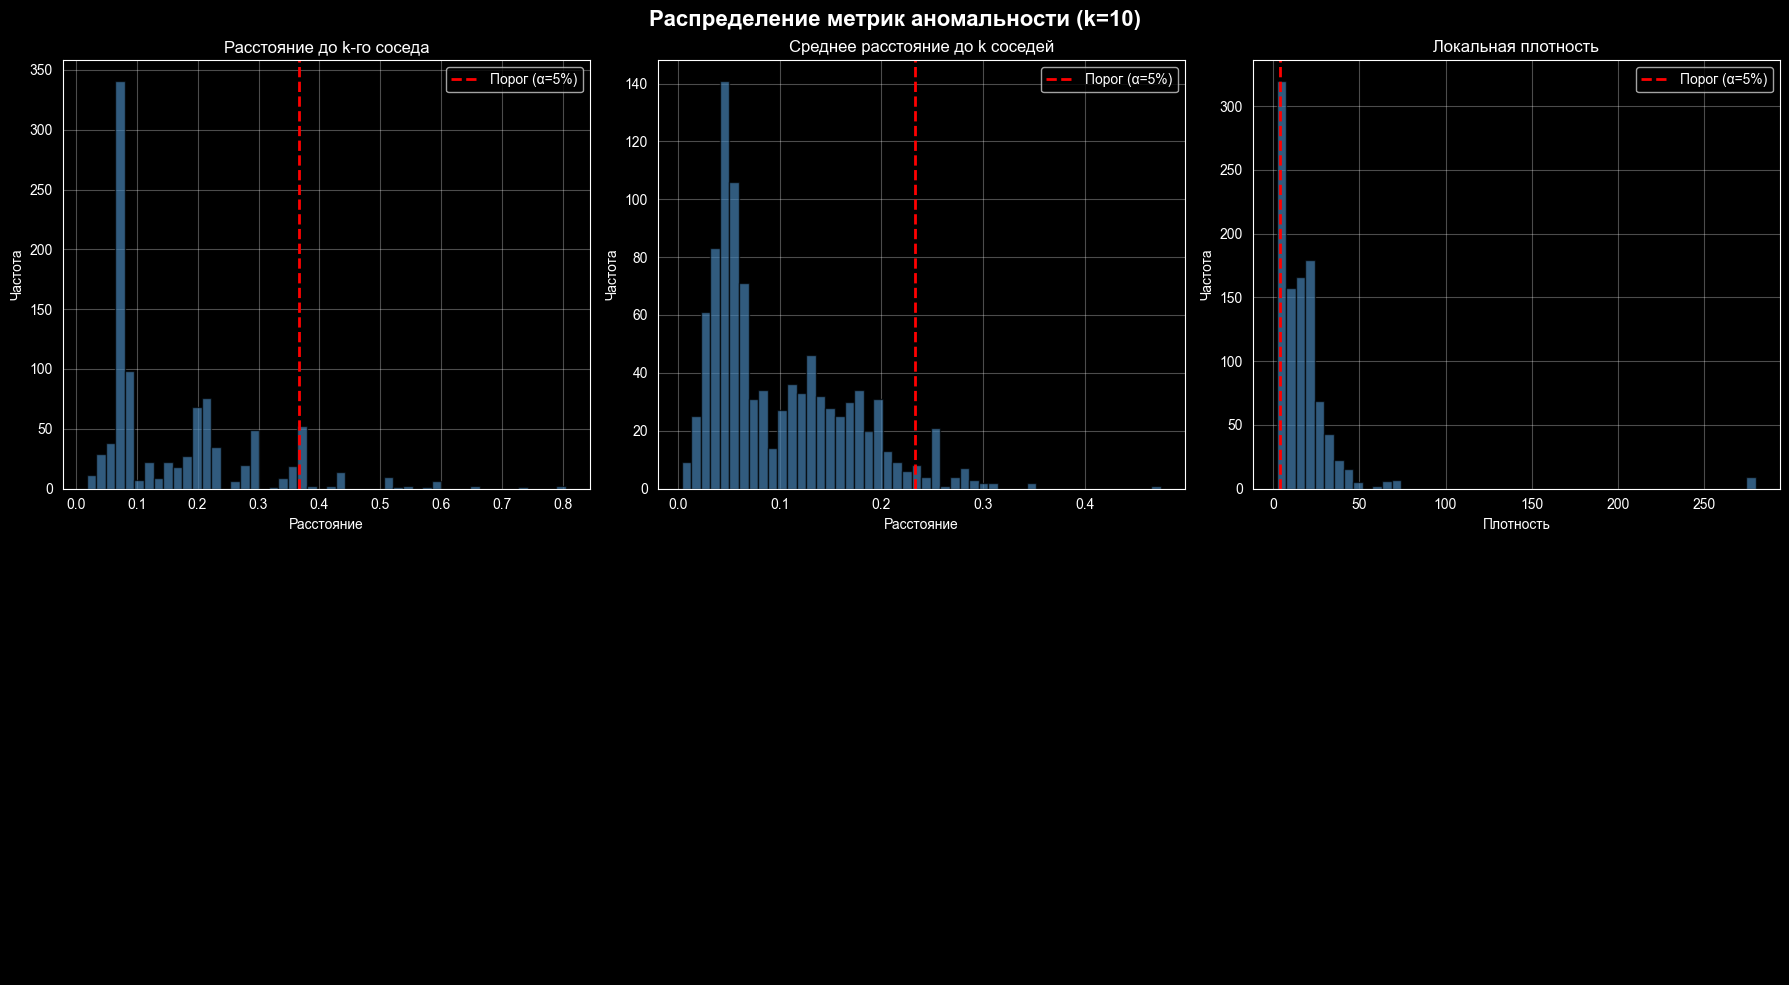



PCA-ВИЗУАЛИЗАЦИЯ АНОМАЛИЙ
Объяснённая дисперсия PCA: 100.00%
  PC1: 53.0%
  PC2: 47.0%


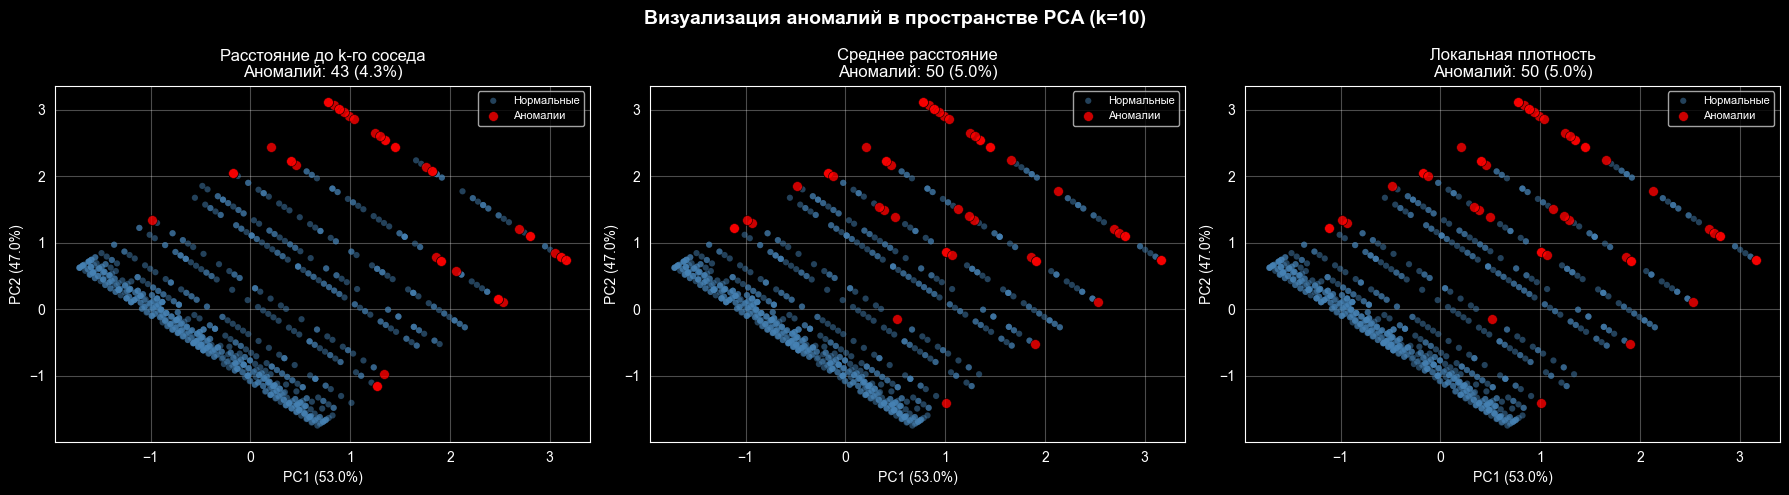



АНАЛИЗ УСТОЙЧИВОСТИ ПРИ ИЗМЕНЕНИИ k

k     Euclidean %     Manhattan %    
-----------------------------------
3     4.50            4.90           
5     5.00            4.30           
7     5.00            5.00           
9     5.00            5.00           
10    5.00            5.00           
15    4.80            4.90           
20    4.90            5.00           


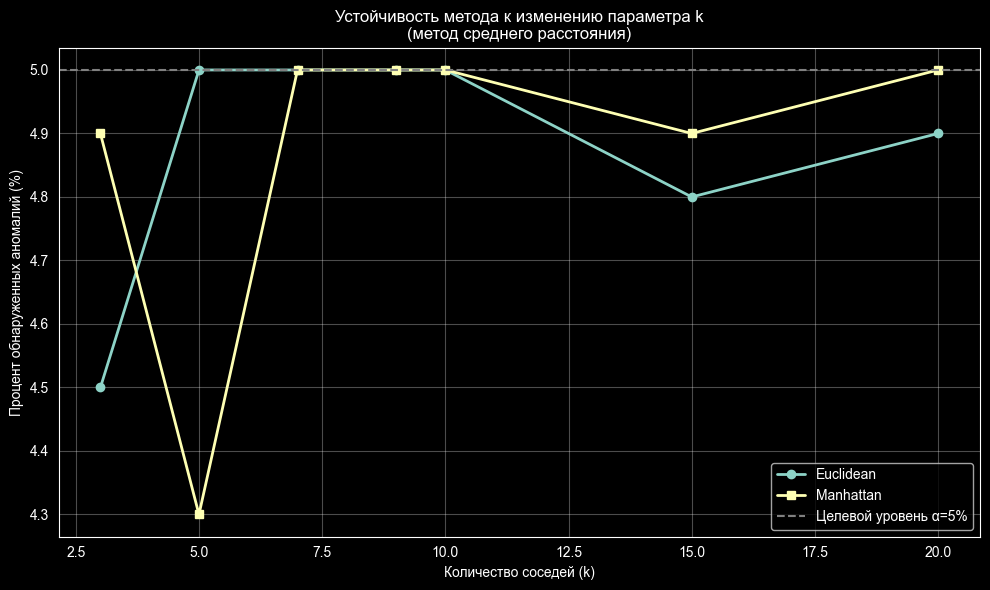



СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТОДОВ
                    Метод   Метрика  k  Аномалий Процент (%)  Порог
Расстояние до k-го соседа Euclidean 10        43        4.30 0.3656
Расстояние до k-го соседа Manhattan 10        50        5.00 0.3997
       Среднее расстояние Euclidean 10        50        5.00 0.2334
       Среднее расстояние Manhattan 10        50        5.00 0.2487
      Локальная плотность Euclidean 10        50        5.00 4.2852
      Локальная плотность Manhattan 10        50        5.00 4.0213


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

df_selected = df[['Age', 'Total Amount']].copy()

# МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
print("\n1. Масштабирование признаков (StandardScaler)")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)
print(f"   Форма данных: {X_scaled.shape}")
print(f"   Среднее после масштабирования: {X_scaled.mean():.2f}")
print(f"   Стандартное отклонение после масштабирования: {X_scaled.std():.2f}")

# РАССТОЯНИЕ ДО k-ГО СОСЕДА
print("\n")
print("МЕТОД 1: РАССТОЯНИЕ ДО k-ГО СОСЕДА")

def kth_neighbor_anomaly_detection(X, k=10, alpha=5, metric='euclidean'):
    # Обнаружение аномалий по расстоянию до k-го ближайшего соседа
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    kth_dist = distances[:, k]  # расстояние до k-го соседа (индекс k, т.к. 0 - сама точка)
    threshold = np.percentile(kth_dist, 100 - alpha)
    outliers_mask = kth_dist > threshold
    return {
        'kth_distances': kth_dist,
        'threshold': threshold,
        'outliers_mask': outliers_mask,
        'outliers_count': outliers_mask.sum(),
        'outliers_percentage': outliers_mask.mean() * 100
    }

k = 10
alpha = 5
results_kth = {}

for metric in ['euclidean', 'manhattan']:
    results_kth[metric] = kth_neighbor_anomaly_detection(X_scaled, k=k, alpha=alpha, metric=metric)
    print(f"\n{metric.capitalize()} расстояние (k={k}):")
    print(f"  Порог: {results_kth[metric]['threshold']:.4f}")
    print(f"  Аномалий: {results_kth[metric]['outliers_count']} ({results_kth[metric]['outliers_percentage']:.2f}%)")

# СРЕДНЕЕ РАССТОЯНИЕ ДО k СОСЕДЕЙ
print("\n")
print("МЕТОД 2: СРЕДНЕЕ РАССТОЯНИЕ ДО k СОСЕДЕЙ")

def avg_k_neighbors_anomaly_detection(X, k=10, alpha=5, metric='euclidean'):
    # Обнаружение аномалий по среднему расстоянию до k ближайших соседей
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    avg_dist = distances[:, 1:].mean(axis=1)  # исключаем саму точку (индекс 0)
    threshold = np.percentile(avg_dist, 100 - alpha)
    outliers_mask = avg_dist > threshold
    return {
        'avg_distances': avg_dist,
        'threshold': threshold,
        'outliers_mask': outliers_mask,
        'outliers_count': outliers_mask.sum(),
        'outliers_percentage': outliers_mask.mean() * 100
    }

k_values = [5, 7, 9, 10]
results_avg = {}

print("Анализ для разных значений k:")
for k in k_values:
    for metric in ['euclidean', 'manhattan']:
        key = f"{metric}_k{k}"
        results_avg[key] = avg_k_neighbors_anomaly_detection(X_scaled, k=k, alpha=alpha, metric=metric)
        print(f"  {metric.capitalize()} (k={k}): {results_avg[key]['outliers_count']} аномалий ({results_avg[key]['outliers_percentage']:.2f}%)")

# ОЦЕНКА ЛОКАЛЬНОЙ ПЛОТНОСТИ
print("\n")
print("МЕТОД 3: ОЦЕНКА ЛОКАЛЬНОЙ ПЛОТНОСТИ")

def local_density_anomaly_detection(X, k=10, alpha=5, metric='euclidean'):
    # Обнаружение аномалий по локальной плотности
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    avg_dist = distances[:, 1:].mean(axis=1)
    density = 1 / (avg_dist + 1e-10)  # +1e-10 для избежания деления на 0
    threshold = np.percentile(density, alpha)  # нижние alpha% считаются аномалиями
    outliers_mask = density < threshold
    return {
        'density': density,
        'threshold': threshold,
        'outliers_mask': outliers_mask,
        'outliers_count': outliers_mask.sum(),
        'outliers_percentage': outliers_mask.mean() * 100
    }

results_density = {}

for k in k_values:
    for metric in ['euclidean', 'manhattan']:
        key = f"{metric}_k{k}"
        results_density[key] = local_density_anomaly_detection(X_scaled, k=k, alpha=alpha, metric=metric)
        print(f"  {metric.capitalize()} (k={k}): {results_density[key]['outliers_count']} аномалий ({results_density[key]['outliers_percentage']:.2f}%)")

# ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ МЕТРИК (k=10)
print("\n")
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ МЕТРИК")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Распределение метрик аномальности (k=10)', fontsize=16, fontweight='bold')

# Данные для визуализации
metrics_data = [
    ('Расстояние до k-го соседа', results_kth['euclidean']['kth_distances'], 'euclidean', 'distance'),
    ('Среднее расстояние до k соседей', results_avg['euclidean_k10']['avg_distances'], 'euclidean', 'distance'),
    ('Локальная плотность', results_density['euclidean_k10']['density'], 'euclidean', 'density'),
]

for idx, (title, data, metric, data_type) in enumerate(metrics_data):
    ax = axes[idx // 3, idx % 3]
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')

    # Определяем порог в зависимости от типа метрики
    if data_type == 'density':
        threshold = results_density['euclidean_k10']['threshold']
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
                   label=f'Порог (α={alpha}%)')
        ax.set_xlabel('Плотность')
    else:
        if title == 'Расстояние до k-го соседа':
            threshold = results_kth['euclidean']['threshold']
        else:
            threshold = results_avg['euclidean_k10']['threshold']
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
                   label=f'Порог (α={alpha}%)')
        ax.set_xlabel('Расстояние')

    ax.set_ylabel('Частота')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

# Скрываем пустые ячейки
for idx in range(3, 6):
    axes[idx // 3, idx % 3].axis('off')

plt.tight_layout()
plt.show()

# PCA-ВИЗУАЛИЗАЦИЯ АНОМАЛИЙ
print("\n")
print("PCA-ВИЗУАЛИЗАЦИЯ АНОМАЛИЙ")
from sklearn.decomposition import PCA
# Применяем PCA для визуализации в 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Объяснённая дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Визуализация аномалий в пространстве PCA (k=10)', fontsize=14, fontweight='bold')

methods = [
    ('Расстояние до k-го соседа', results_kth['euclidean']['outliers_mask']),
    ('Среднее расстояние', results_avg['euclidean_k10']['outliers_mask']),
    ('Локальная плотность', results_density['euclidean_k10']['outliers_mask']),
]

for idx, (name, mask) in enumerate(methods):
    ax = axes[idx]
    # Нормальные точки
    ax.scatter(X_pca[~mask, 0], X_pca[~mask, 1],
               c='steelblue', alpha=0.5, s=20, label='Нормальные', edgecolors='none')
    # Аномалии
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c='red', alpha=0.8, s=50, label='Аномалии',
               edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'{name}\nАномалий: {mask.sum()} ({mask.mean()*100:.1f}%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# АНАЛИЗ УСТОЙЧИВОСТИ ПРИ ИЗМЕНЕНИИ k
print("\n")
print("АНАЛИЗ УСТОЙЧИВОСТИ ПРИ ИЗМЕНЕНИИ k")

k_range = [3, 5, 7, 9, 10, 15, 20]
stability_results = {'euclidean': [], 'manhattan': []}

print(f"\n{'k':<5} {'Euclidean %':<15} {'Manhattan %':<15}")
print("-" * 35)

for k in k_range:
    eucl_result = avg_k_neighbors_anomaly_detection(X_scaled, k=k, alpha=alpha, metric='euclidean')
    manh_result = avg_k_neighbors_anomaly_detection(X_scaled, k=k, alpha=alpha, metric='manhattan')
    stability_results['euclidean'].append((k, eucl_result['outliers_percentage']))
    stability_results['manhattan'].append((k, manh_result['outliers_percentage']))
    print(f"{k:<5} {eucl_result['outliers_percentage']:<15.2f} {manh_result['outliers_percentage']:<15.2f}")

# График устойчивости
plt.figure(figsize=(10, 6))
plt.plot([r[0] for r in stability_results['euclidean']],
         [r[1] for r in stability_results['euclidean']],
         marker='o', label='Euclidean', linewidth=2)
plt.plot([r[0] for r in stability_results['manhattan']],
         [r[1] for r in stability_results['manhattan']],
         marker='s', label='Manhattan', linewidth=2)
plt.axhline(y=alpha, color='gray', linestyle='--', label=f'Целевой уровень α={alpha}%')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Процент обнаруженных аномалий (%)')
plt.title('Устойчивость метода к изменению параметра k\n(метод среднего расстояния)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТОДОВ
print("\n")
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТОДОВ")

comparison_data = []

for k in [10]:
    # Метод 1: Расстояние до k-го соседа
    for metric in ['euclidean', 'manhattan']:
        r = results_kth[metric]
        comparison_data.append({
            'Метод': 'Расстояние до k-го соседа',
            'Метрика': metric.capitalize(),
            'k': k,
            'Аномалий': r['outliers_count'],
            'Процент (%)': f"{r['outliers_percentage']:.2f}",
            'Порог': f"{r['threshold']:.4f}"
        })

    # Метод 2: Среднее расстояние
    for metric in ['euclidean', 'manhattan']:
        key = f"{metric}_k{k}"
        r = results_avg[key]
        comparison_data.append({
            'Метод': 'Среднее расстояние',
            'Метрика': metric.capitalize(),
            'k': k,
            'Аномалий': r['outliers_count'],
            'Процент (%)': f"{r['outliers_percentage']:.2f}",
            'Порог': f"{r['threshold']:.4f}"
        })

    # Метод 3: Локальная плотность
    for metric in ['euclidean', 'manhattan']:
        key = f"{metric}_k{k}"
        r = results_density[key]
        comparison_data.append({
            'Метод': 'Локальная плотность',
            'Метрика': metric.capitalize(),
            'k': k,
            'Аномалий': r['outliers_count'],
            'Процент (%)': f"{r['outliers_percentage']:.2f}",
            'Порог': f"{r['threshold']:.4f}"
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
